# Homer Comparison

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import os


In [29]:
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# this uses Homer's default residential summer load profile
f = 'elite_charge_discharge_homer_summer_load_sept21.csv'#elite_charge_discharge_homer_summer_load_sept21.csv'

directory = f"homer/{f}"   # update if the file lives elsewhere

def ts():
    """Timestamp string for filenames, e.g. 20260920_143005"""
    return datetime.now().strftime("%Y%m%d_%H%M%S")

In [30]:
# Row 1 = "sep=," Excel hint, row 2 = header, row 3 = units row
units_row = pd.read_csv(directory, skiprows=2, nrows=1, header=None).iloc[0].tolist()
df = pd.read_csv(directory, skiprows=[0, 2])
units = dict(zip(df.columns, units_row))

df["Time"] = pd.to_datetime(df["Time"], format="%m/%d/%Y %I:%M:%S %p")
df = df.set_index("Time")

# ---- Simulation time step, read from the data (60 min for hourly exports, 1 min for 1-minute exports) ----
# Power columns are kW, so kW x dt_h = kWh per row. Use these helpers wherever a power column is summed into
# energy, or a row count is reported as hours.
step = df.index.to_series().diff().mode().iloc[0]      # e.g. Timedelta('0 days 00:01:00')
dt_h = step / pd.Timedelta(hours=1)                    # e.g. 1/60 h
step_min = dt_h * 60

def to_kwh(power_kw):
    """Sum a kW column into kWh (accounts for the time step)."""
    return power_kw.sum() * dt_h

def to_hours(n_rows):
    """Convert a row count into hours (accounts for the time step)."""
    return n_rows * dt_h

irregular = (df.index.to_series().diff().dropna() != step).sum()
print(f"Time step: {step_min:g} min | rows: {len(df):,} | {df.index[0]} to {df.index[-1] + step}"
      + (f" | WARNING: {irregular} irregular gaps" if irregular else ""))

print(df.shape)
display(df.head(3).T)

Time step: 1 min | rows: 525,600 | 2024-01-01 00:00:00 to 2024-12-31 00:00:00
(525600, 28)


Time,2024-01-01 00:00:00,2024-01-01 00:01:00,2024-01-01 00:02:00
AC Primary Load,9.242073e-02,9.242073e-02,9.242073e-02
AC Primary Load Served,9.242073e-02,9.242073e-02,9.242073e-02
Deferrable Load Served,0.000000e+00,0.000000e+00,0.000000e+00
Deferrable Load Storage Level,0.000000e+00,0.000000e+00,0.000000e+00
Grid Power Price,3.000000e-01,3.000000e-01,3.000000e-01
Grid Sellback Rate,0.000000e+00,0.000000e+00,0.000000e+00
Grid Purchases,0.000000e+00,0.000000e+00,0.000000e+00
Total Electrical Load Served,9.242073e-02,9.242073e-02,9.242073e-02
Renewable Penetration,0.000000e+00,0.000000e+00,0.000000e+00
Unmet Electrical Load,0.000000e+00,0.000000e+00,0.000000e+00


In [31]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 525600 entries, 2024-01-01 00:00:00 to 2024-12-30 23:59:00
Data columns (total 28 columns):
 #   Column                                                   Non-Null Count   Dtype  
---  ------                                                   --------------   -----  
 0   AC Primary Load                                          525600 non-null  float64
 1   AC Primary Load Served                                   525600 non-null  float64
 2   Deferrable Load Served                                   525600 non-null  int64  
 3   Deferrable Load Storage Level                            525600 non-null  int64  
 4   Grid Power Price                                         525600 non-null  float64
 5   Grid Sellback Rate                                       525600 non-null  int64  
 6   Grid Purchases                                           525600 non-null  float64
 7   Total Electrical Load Served                             525600 non-null  floa

In [32]:
summary = df.describe().T[["mean", "std", "min", "max"]]
summary.insert(0, "unit", pd.Series(units))
summary["n_unique"] = df.nunique()
summary["pct_zero"] = ((df == 0).mean() * 100).round(1)
display(summary.round(4))
print("Constant columns:", summary.index[summary["n_unique"] == 1].tolist())

,unit,mean,std,min,max,n_unique,pct_zero
AC Primary Load,kW,4.696000e-01,2.980000e-01,0.0231,2.236500e+00,8756,0.0
AC Primary Load Served,kW,4.599000e-01,2.998000e-01,0.0000,2.236500e+00,8974,1.2
Deferrable Load Served,kW,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Deferrable Load Storage Level,kWh,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Grid Power Price,$/kWh,-1.662500e+02,3.724175e+02,-999.0000,3.000000e-01,2,0.0
Grid Sellback Rate,$/kWh,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Grid Purchases,kW,4.764000e-01,6.352000e-01,0.0000,4.036500e+00,8015,16.7
Total Electrical Load Served,kW,4.599000e-01,2.998000e-01,0.0000,2.236500e+00,8974,1.2
Renewable Penetration,%,0.000000e+00,0.000000e+00,0.0000,0.000000e+00,1,100.0
Unmet Electrical Load,kW,9.700000e-03,8.800000e-02,0.0000,1.278100e+00,463,98.7


Constant columns: ['Deferrable Load Served', 'Deferrable Load Storage Level', 'Grid Sellback Rate', 'Renewable Penetration', 'Total Renewable Power Output', 'DC Required Operating Capacity']


In [33]:
# ---- helpers: work with any of the export variants (outage-style, price-style, with/without standby columns) ----
def event_info(frame):
    """Return (event mask, description). Event hours are found from whichever signal the export has:
      1) grid unavailable  -> AC Operating Capacity == 0            (outage-style exports)
      2) grid price change -> price differs from the base (most common) price;
                              the event price can be higher OR lower than the base   (price-style exports)"""
    if "AC Operating Capacity" in frame.columns and (frame["AC Operating Capacity"] == 0).any():
        return frame["AC Operating Capacity"] == 0, "grid unavailable (AC Operating Capacity == 0)"
    if "Grid Power Price" in frame.columns and frame["Grid Power Price"].nunique() > 1:
        price = frame["Grid Power Price"]
        base = price.mode().iloc[0]
        ev_prices = sorted(price[price != base].unique().tolist())
        direction = "lower" if max(ev_prices) < base else "higher" if min(ev_prices) > base else "mixed"
        return price != base, f"grid price differs from the base price {base} -> event price(s) {ev_prices} ({direction} than base)"
    return pd.Series(False, index=frame.index), "no event signal found (no AC Operating Capacity zeros, no price change)"

def event_mask(frame):
    return event_info(frame)[0]

def ac_served(frame):
    """AC load actually served: the export's own column if present, otherwise total served minus the deferrable (standby) load."""
    if "AC Primary Load Served" in frame.columns:
        return frame["AC Primary Load Served"]
    deferrable = frame["Deferrable Load Served"] if "Deferrable Load Served" in frame.columns else 0
    return frame["Total Electrical Load Served"] - deferrable

In [34]:
# soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
# chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
# dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"

# df["event"], event_text = event_info(df)
# ev = df["event"]
# run_id = (ev != ev.shift()).cumsum()

# print("Event signal:", event_text)
# print("Event hours:", ev.sum(), f"({ev.mean():.1%}) over", ev.groupby(df.index.normalize()).any().sum(), "days")
# print("Hours of day affected:", sorted(df.index[ev].hour.unique().tolist()))
# print("Days of week affected (0=Mon):", sorted(df.index[ev].dayofweek.unique().tolist()))
# print("Run lengths (hours):", df[ev].groupby(run_id[ev]).size().value_counts().to_dict())

# print(f"Battery: charges in {(df[chg_col] > 0).sum()} h, discharges in {(df[dis_col] > 0).sum()} h "
#       f"({((df[dis_col] > 0) & ~ev).sum()} h of discharge outside events), SoC range {df[soc_col].min():.1f}-{df[soc_col].max():.1f}%")

# unserved = (df["AC Primary Load"] - ac_served(df)).clip(lower=0)
# print(f"AC load unserved: {unserved.sum():.1f} of {df['AC Primary Load'].sum():.1f} kWh "
#       f"({unserved.sum() / df['AC Primary Load'].sum():.1%}); hours of day: {sorted(df.index[unserved > 1e-9].hour.unique().tolist())}")
soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"

df["event"], event_text = event_info(df)
ev = df["event"]
run_id = (ev != ev.shift()).cumsum()

print("Event signal:", event_text)
print("Event hours:", f"{to_hours(ev.sum()):g}", f"({ev.mean():.1%}) over", ev.groupby(df.index.normalize()).any().sum(), "days")
print("Hours of day affected:", sorted(df.index[ev].hour.unique().tolist()))
print("Days of week affected (0=Mon):", sorted(df.index[ev].dayofweek.unique().tolist()))
run_hours = (df[ev].groupby(run_id[ev]).size() * dt_h).round(4).value_counts()
print("Run lengths (hours):", {(int(k) if k == int(k) else k): v for k, v in run_hours.items()})

print(f"Battery: charges in {to_hours((df[chg_col] > 0).sum()):g} h, discharges in {to_hours((df[dis_col] > 0).sum()):g} h "
      f"({to_hours(((df[dis_col] > 0) & ~ev).sum()):g} h of discharge outside events), SoC range {df[soc_col].min():.1f}-{df[soc_col].max():.1f}%")

unserved = (df["AC Primary Load"] - ac_served(df)).clip(lower=0)
print(f"AC load unserved: {to_kwh(unserved):.1f} of {to_kwh(df['AC Primary Load']):.1f} kWh "
      f"({unserved.sum() / df['AC Primary Load'].sum():.1%}); hours of day: {sorted(df.index[unserved > 1e-9].hour.unique().tolist())}")

Event signal: grid unavailable (AC Operating Capacity == 0)
Event hours: 1460 (16.7%) over 365 days
Hours of day affected: [14, 15, 16, 17]
Days of week affected (0=Mon): [0, 1, 2, 3, 4, 5, 6]
Run lengths (hours): {4: 365}
Battery: charges in 424.833 h, discharges in 1360.83 h (7.21667 h of discharge outside events), SoC range 5.0-100.0%
AC load unserved: 84.8 of 4113.6 kWh (2.1%); hours of day: [16, 17]


In [35]:
# eng_col = "Elite 200V2 LFP 2kWh DC Coupled Energy Content"

# if "Deferrable Load Served" not in df.columns:
#     print("No 'Deferrable Load Served' column in this export (standby load not modeled).")
# else:
#     sb = df["Deferrable Load Served"]   # the DC standby load (self consumption) shows up here
#     idle = (~ev) & (df[chg_col] == 0) & (df[dis_col] == 0)   # not an event, battery not charging or discharging
#     hrs = sorted(df.index[sb == 0].hour.unique().tolist())

#     print("Standby power when served (kW):", sorted(sb[sb > 0].round(5).unique().tolist()))
#     print(f"Standby average: {sb.mean() * 1000:.2f} W ({sb.sum():.1f} kWh/yr) | hours with none served: {(sb == 0).sum()}"
#           f" ({hrs if len(hrs) <= 6 else 'spread across the day'})")
#     print("--- battery idle, not an event ---")
#     print("Battery energy change (kWh/hr):", sorted(df[eng_col].diff()[idle].dropna().round(6).unique().tolist()))
#     m = idle & (sb > 0)
#     print("Grid energy per unit of standby served:", sorted(((df["Grid Purchases"] - ac_served(df))[m] / sb[m]).round(3).unique().tolist()),
#           "(1.111 = served by the grid through a 90% efficient rectifier)")
#     print("--- during events ---")
#     print("Discharge minus inverter input (kW):", sorted((df[dis_col] - df["Inverter Power Input"])[ev].round(6).unique().tolist()),
#           "(non-zero = battery serves the standby load directly)")
eng_col = "Elite 200V2 LFP 2kWh DC Coupled Energy Content"

if "Deferrable Load Served" not in df.columns:
    print("No 'Deferrable Load Served' column in this export (standby load not modeled).")
else:
    sb = df["Deferrable Load Served"]   # the DC standby load (self consumption) shows up here
    idle = (~ev) & (df[chg_col] == 0) & (df[dis_col] == 0)   # not an event, battery not charging or discharging
    hrs_none = sorted(df.index[sb == 0].hour.unique().tolist())   # hours of the day with no standby served

    print("Standby power when served (kW):", sorted(sb[sb > 0].round(5).unique().tolist()))
    print(f"Standby average: {sb.mean() * 1000:.2f} W ({to_kwh(sb):.1f} kWh/yr) | hours with none served: {to_hours((sb == 0).sum()):g}"
          f" ({hrs_none if len(hrs_none) <= 6 else 'spread across the day'})")
    print("--- battery idle, not an event ---")
    # energy change per row -> per hour (= kW), so the numbers are comparable at any time step
    d_eng = (df[eng_col].diff() / dt_h)[idle].dropna()
    nd = 6 if dt_h >= 1 else 4      # sub-hourly: export rounding is amplified by 1/dt_h, so round coarser
    vals = sorted(d_eng.round(nd).unique().tolist())
    print("Battery energy change (kWh/hr):",
          vals if len(vals) <= 6 else f"median {d_eng.median():.{nd}f} (range {d_eng.min():.{nd}f} to {d_eng.max():.{nd}f}; {len(vals)} distinct values from export rounding)")
    m = idle & (sb > 0)
    print("Grid energy per unit of standby served:", sorted(((df["Grid Purchases"] - ac_served(df))[m] / sb[m]).round(3).unique().tolist()),
          "(1.111 = served by the grid through a 90% efficient rectifier)")
    print("--- during events ---")
    print("Discharge minus inverter input (kW):", sorted((df[dis_col] - df["Inverter Power Input"])[ev].round(6).unique().tolist()),
          "(non-zero = battery serves the standby load directly)")

Standby power when served (kW): []
Standby average: 0.00 W (0.0 kWh/yr) | hours with none served: 8760 (spread across the day)
--- battery idle, not an event ---
Battery energy change (kWh/hr): [0.0]
Grid energy per unit of standby served: [] (1.111 = served by the grid through a 90% efficient rectifier)
--- during events ---
Discharge minus inverter input (kW): [0.0] (non-zero = battery serves the standby load directly)


Event signal: grid unavailable (AC Operating Capacity == 0)
Event starts this week: ['Mon 14:00', 'Tue 14:00', 'Wed 14:00', 'Thu 14:00', 'Fri 14:00', 'Sat 14:00', 'Sun 14:00']


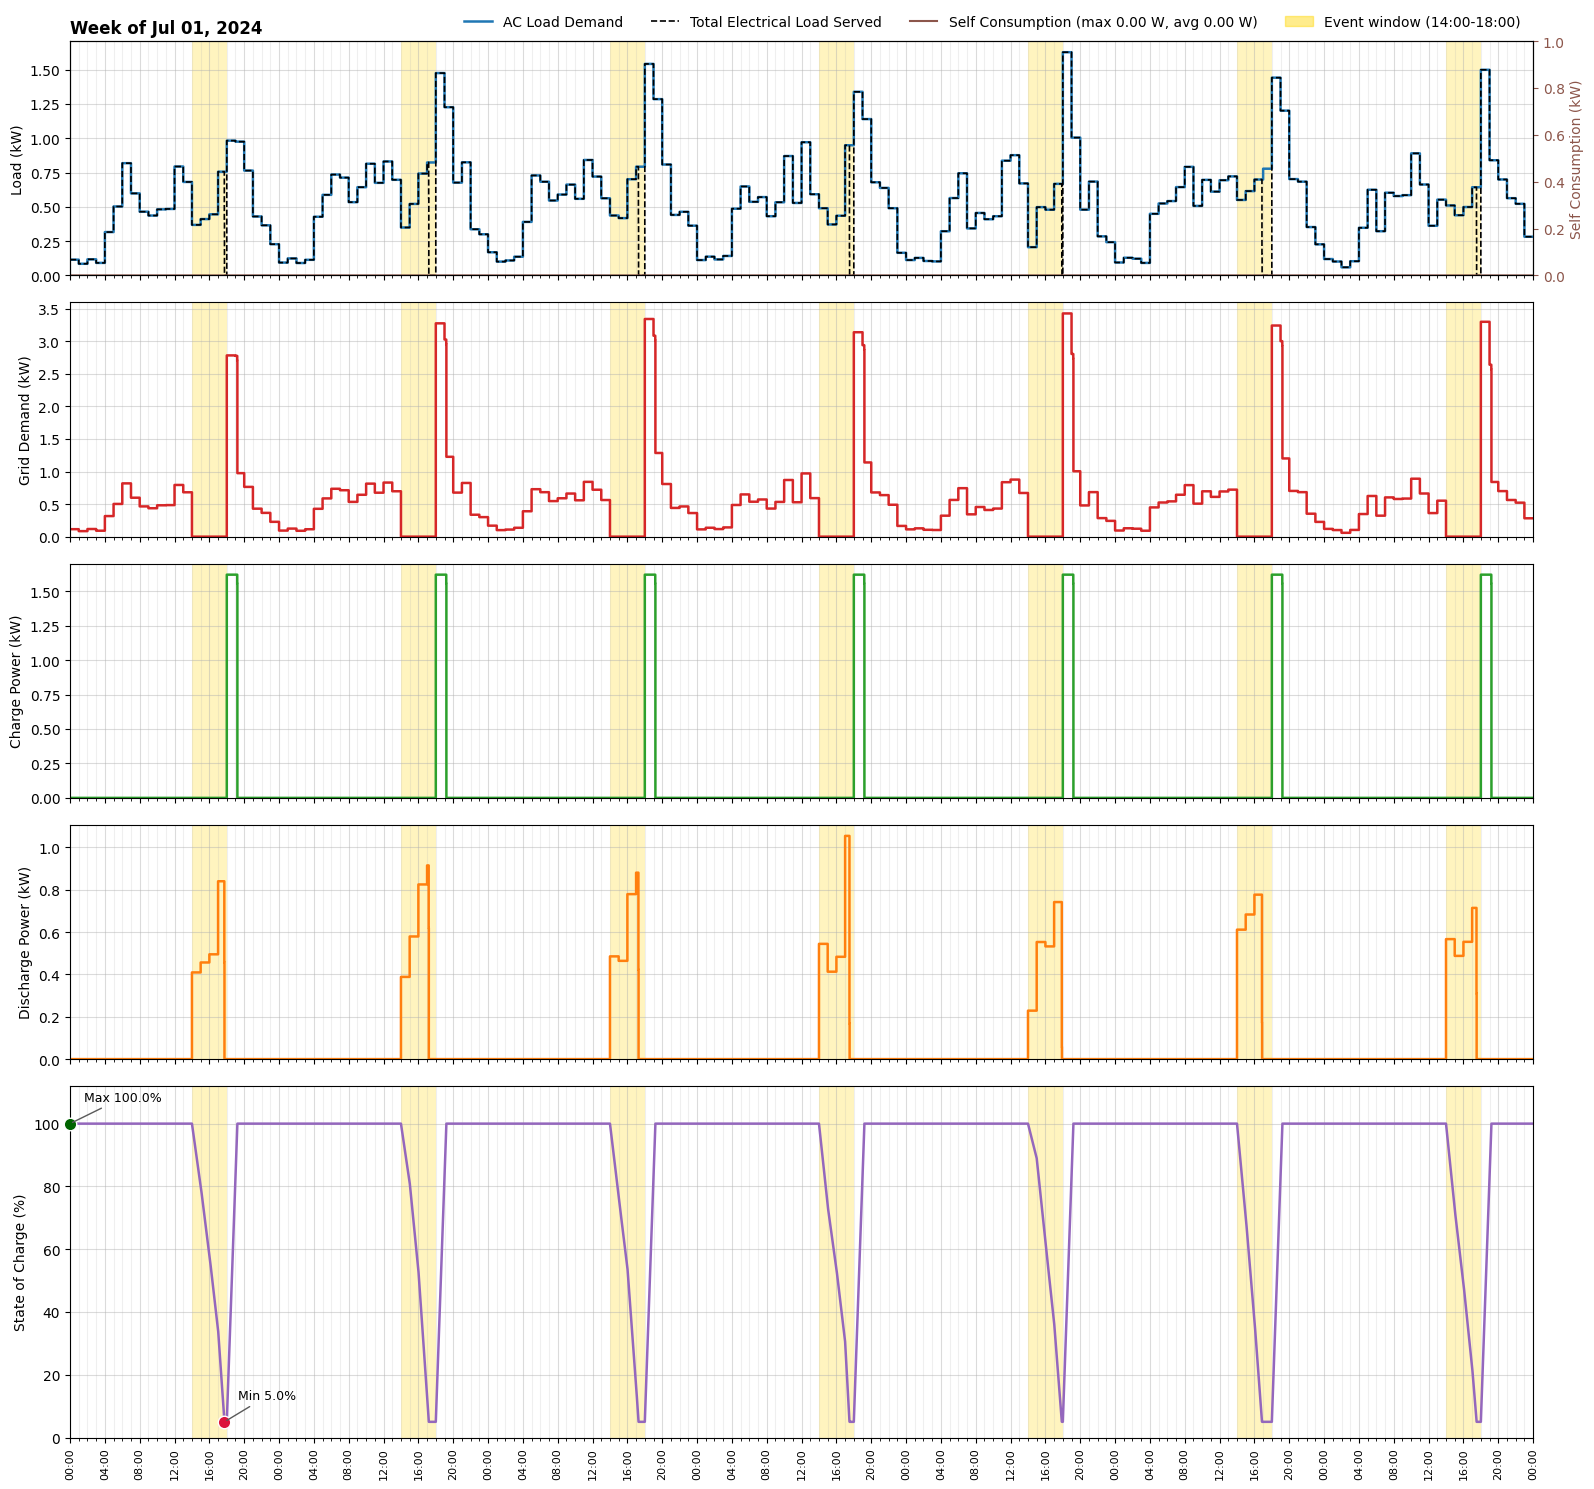

In [36]:
# plt.tight_layout()
# #fig.savefig(f"plots/july_week_{WEEK_START}_{ts()}.png", dpi=150, bbox_inches="tight")
# plt.show()
WEEK_START = "2024-07-01"   # change to view a different week
TICK_HOURS = 4              # labeled tick spacing (hours); gridlines are always hourly
SHIFT_SOC_TO_STEP_END = True    # True: plot each SoC at the END of its time step (how HOMER reports it); False: at the start
SELF_CONSUMPTION_OWN_AXIS = True   # True: right-hand axis (readable at ~9 W); False: same kW axis as the load

soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"
grid_col = "Grid Purchases"   # kW imported from the grid = grid demand

start = pd.Timestamp(WEEK_START)
wk = df.loc[start : start + pd.Timedelta(days=7) - step]   # step = the data's time step (1 min or 1 h)

fig, axes = plt.subplots(5, 1, figsize=(16, 15), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1, 1.5]})

# 1) Loads: demand vs. what was served (they differ when the battery runs out during an event)
axes[0].plot(wk.index, wk["AC Primary Load"], drawstyle="steps-post", lw=1.8, label="AC Load Demand")
axes[0].plot(wk.index, wk["Total Electrical Load Served"], drawstyle="steps-post", lw=1.2, ls="--", color="k", label="Total Electrical Load Served")
axes[0].set(ylabel="Load (kW)")
axes[0].set_title(f"Week of {start:%b %d, %Y}", loc="left", fontweight="bold")

# Self consumption = the DC standby load (Deferrable Load Served) -- only if this export has it
sc_handles = []
if "Deferrable Load Served" in wk.columns:
    sc = wk["Deferrable Load Served"]
    sc_label = f"Self Consumption (max {df['Deferrable Load Served'].max() * 1000:.2f} W, avg {df['Deferrable Load Served'].mean() * 1000:.2f} W)"
    sc_color = "tab:brown"
    if SELF_CONSUMPTION_OWN_AXIS:
        ax_sc = axes[0].twinx()
        ax_sc.plot(wk.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)
        ax_sc.set_ylim(0, sc.max() * 1.5 if sc.max() > 0 else 1)
        ax_sc.set_ylabel("Self Consumption (kW)", color=sc_color)
        ax_sc.tick_params(axis="y", colors=sc_color)
        sc_handles = ax_sc.get_lines()
    else:
        axes[0].plot(wk.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)

# 2) Grid demand (Grid Purchases)
axes[1].plot(wk.index, wk[grid_col], drawstyle="steps-post", color="tab:red", lw=1.8)
axes[1].set(ylabel="Grid Demand (kW)")

# 3) Charge power
axes[2].plot(wk.index, wk[chg_col], drawstyle="steps-post", color="tab:green", lw=1.8)
axes[2].set(ylabel="Charge Power (kW)")

# 4) Discharge power
axes[3].plot(wk.index, wk[dis_col], drawstyle="steps-post", color="tab:orange", lw=1.8)
axes[3].set(ylabel="Discharge Power (kW)")

# 5) State of charge, with the week's min and max labeled
if SHIFT_SOC_TO_STEP_END:
    # HOMER's SoC in each row is the value at the END of that time step, so it belongs one step later on the time axis.
    # Start one row early: the previous row's SoC is the state at the start of the week, so the curve has no gap on the left.
    soc = df[soc_col].loc[start - step : wk.index[-1]].copy()
    soc.index = soc.index + step
else:
    soc = wk[soc_col].copy()
axes[4].plot(soc.index, soc, color="tab:purple", lw=1.8)
axes[4].set(ylabel="State of Charge (%)")
axes[4].set_ylim(0, 112)                   # always starts at 0; headroom above 100% for the Max label
axes[4].set_yticks(range(0, 101, 20))

if soc.max() == soc.min():                 # flat line (e.g. the battery never cycles): one label instead of two
    extremes = [(soc.idxmax(), "Constant")]
else:
    extremes = [(soc.idxmax(), "Max"), (soc.idxmin(), "Min")]   # first occurrence if tied
for t, kind in extremes:
    v, is_min = soc.loc[t], kind == "Min"
    axes[4].plot(t, v, marker="o", ms=9, mfc={"Max": "darkgreen", "Min": "crimson", "Constant": "gray"}[kind],
                 mec="white", ls="none", zorder=5, clip_on=False)
    frac = (t - soc.index[0]) / (soc.index[-1] - soc.index[0])    # keep labels inside the axes near the edges
    ha = "left" if frac < 0.06 else "right" if frac > 0.94 else "center"
    below = is_min and v > 0.2 * axes[4].get_ylim()[1]            # Min label goes below the dot only if there is room
    if is_min and not below and ha == "center":
        ha = "left"                                               # near the 0 line: put the label up and beside the dot
    dx = {"left": 10, "right": -10, "center": 0}[ha]
    axes[4].annotate(f"{kind} {v:.1f}%", xy=(t, v),
                     xytext=(dx, -14 if below else 14), textcoords="offset points",
                     ha=ha, va="top" if below else "bottom", fontsize=9, #fontweight="bold",
                     arrowprops=dict(arrowstyle="-", color="0.35"),
                     #bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="0.5", alpha=0.95),
                     zorder=6)

# Shade event windows on every panel (start/end are read from the data)
all_event, event_text = event_info(df)
event = all_event.loc[wk.index]
run_id = (event != event.shift()).cumsum()
for _, g in wk[event].groupby(run_id[event]):
    for ax in axes:
        ax.axvspan(g.index[0], g.index[-1] + step, color="gold", alpha=0.25, lw=0)
for ax in axes[:4]:
    ax.set_ylim(bottom=0)   # y-axes always start at 0
starts = wk.index[event & ~event.shift(fill_value=False)]
print("Event signal:", event_text)
print("Event starts this week:", [t.strftime("%a %H:%M") for t in starts])
if wk[chg_col].max() == 0 and wk[dis_col].max() == 0:
    print("Note: the battery neither charges nor discharges this week.")

extra = []
if all_event.any():
    tod = df.index[all_event].hour * 60 + df.index[all_event].minute            # minute of day for every event row
    t0, t1 = int(tod.min()), int(tod.max() + step_min)                          # window start / end (end = last row + one step)
    extra = [Patch(color="gold", alpha=0.45, label=f"Event window ({t0 // 60:02d}:{t0 % 60:02d}-{(t1 // 60) % 24:02d}:{t1 % 60:02d})")]
axes[0].legend(handles=axes[0].get_lines() + sc_handles + extra,
               loc="lower right", bbox_to_anchor=(1, 1.0), ncol=4, frameon=False)

# X-axis: labeled ticks every TICK_HOURS, hourly gridlines
axes[-1].xaxis.set_major_locator(mdates.HourLocator(interval=TICK_HOURS))
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(interval=1))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].tick_params(axis="x", which="major", labelsize=8, labelrotation=90)
axes[-1].set_xlim(wk.index[0], wk.index[-1] + step)

for ax in axes:
    ax.grid(which="minor", axis="x", alpha=0.20)   # hourly
    ax.grid(which="major", axis="both", alpha=0.45)

plt.tight_layout()
#fig.savefig(f"plots/july_week_{WEEK_START}_{ts()}.png", dpi=150, bbox_inches="tight")
plt.show()

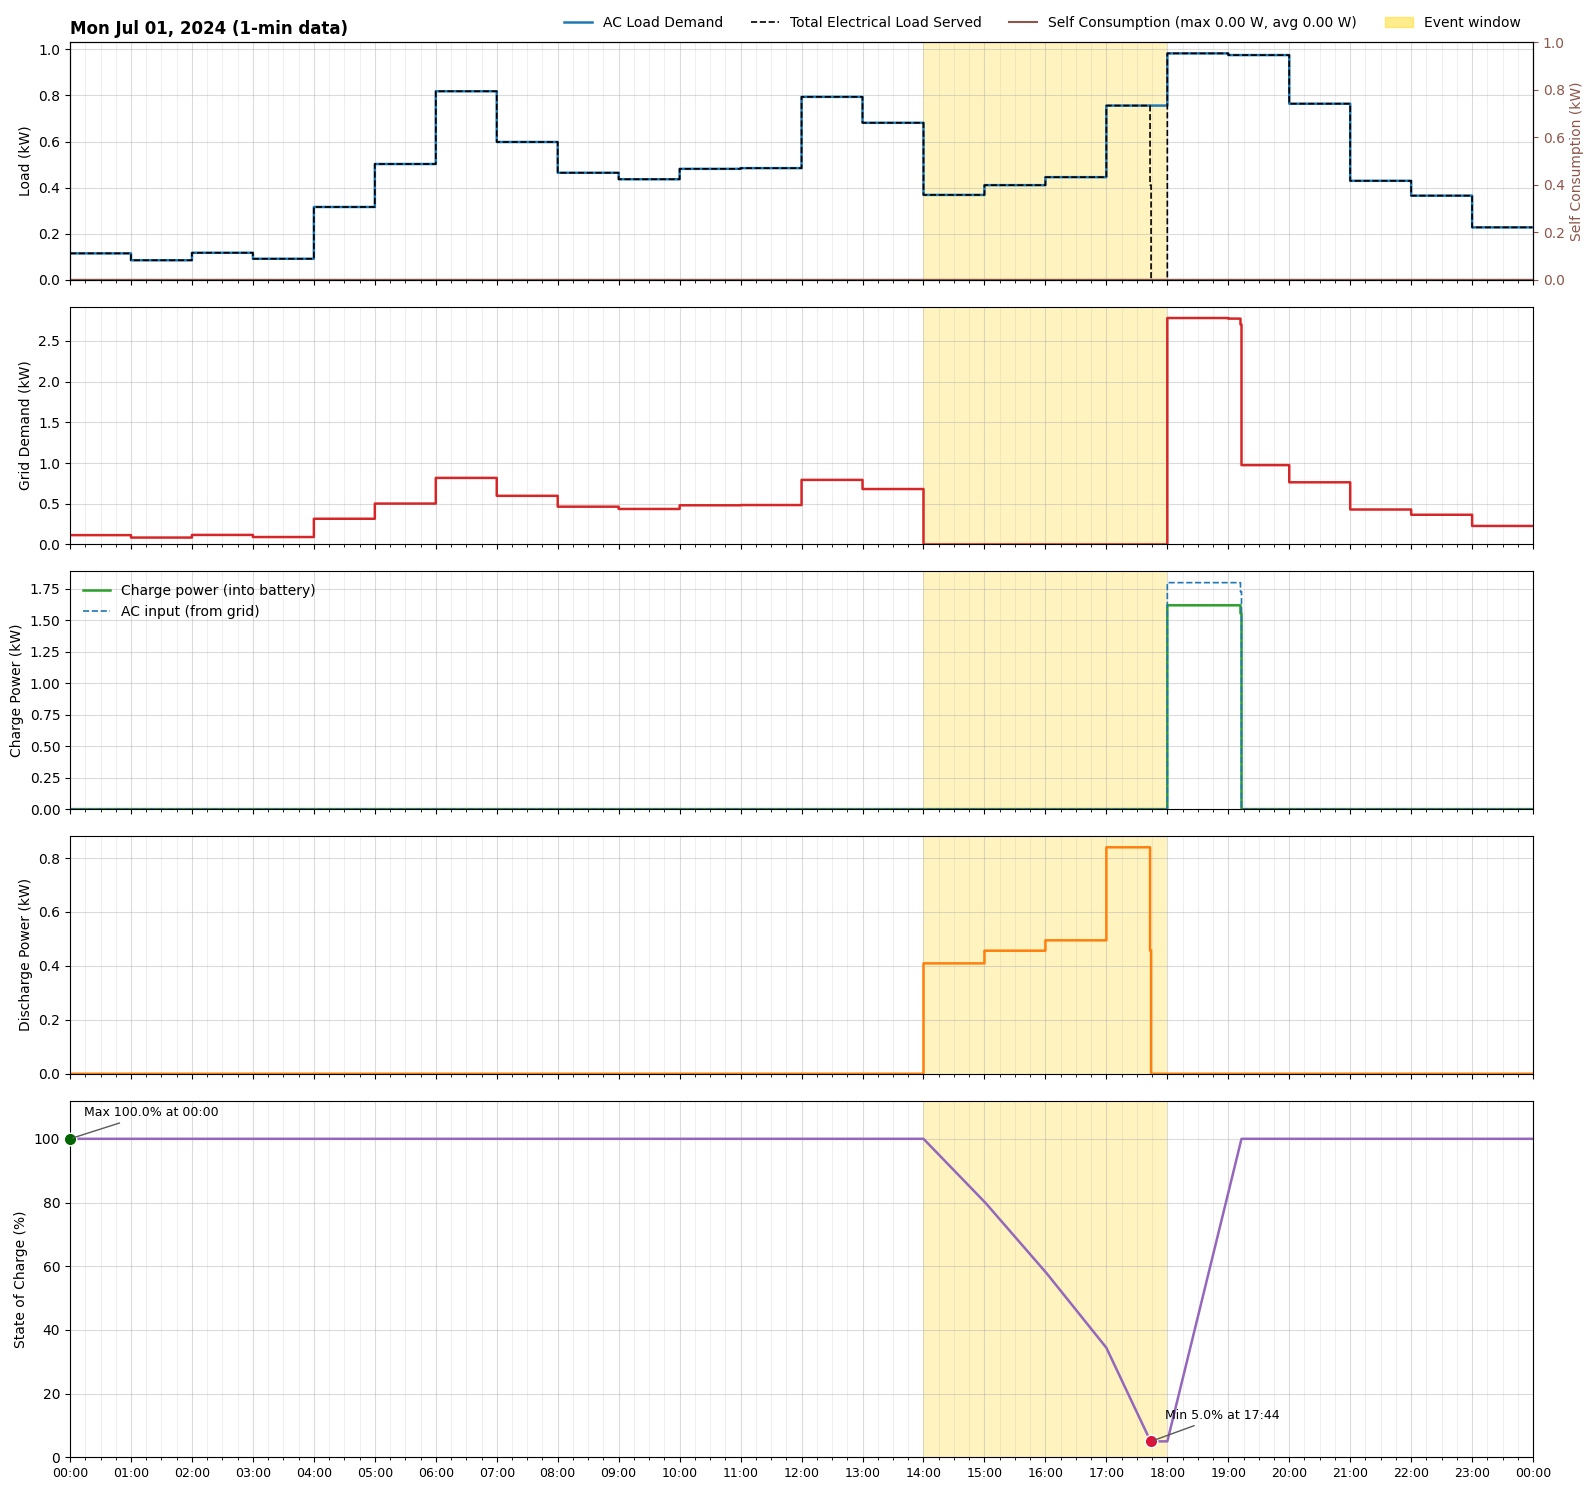

Event signal: grid unavailable (AC Operating Capacity == 0)
Event: 14:00 - 18:00 (4 h)
Charging (first to last charging row): 18:00 - 19:13 | into battery 1.970 kWh, AC input 2.189 kWh
Battery discharge: 1.970 kWh | grid purchases: 11.916 kWh | AC load unserved: 0.207 kWh


In [37]:
# ---- One-day zoom at the data's native time step (minute intervals) ----
DAY = "2024-07-01"          # the day to plot
ZOOM_TO = None              # None = whole day; or e.g. ("13:00", "20:00") to zoom in on part of the day
TICK_MINUTES = 60           # labeled tick spacing (minutes)
GRID_MINUTES = 15           # minor gridline spacing (minutes)
SHOW_AC_INPUT = True        # also draw the AC input (grid -> charger) on the charge power panel
SHIFT_SOC_TO_STEP_END = True    # True: plot each SoC at the END of its time step (how HOMER reports it); False: at the start
SELF_CONSUMPTION_OWN_AXIS = True   # True: right-hand axis (readable at ~9 W); False: same kW axis as the load

soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"
grid_col = "Grid Purchases"          # kW imported from the grid = grid demand
ac_in_col = "Rectifier Power Input"  # AC kW pulled from the grid into the inverter/charger

t_start = pd.Timestamp(f"{DAY} {ZOOM_TO[0]}") if ZOOM_TO else pd.Timestamp(DAY)
t_end   = pd.Timestamp(f"{DAY} {ZOOM_TO[1]}") if ZOOM_TO else pd.Timestamp(DAY) + pd.Timedelta(days=1)
d = df.loc[t_start : t_end - step]
if d.empty:
    raise ValueError(f"No rows between {t_start} and {t_end}: check DAY / ZOOM_TO against the data range {df.index[0]} to {df.index[-1]}")

def clock_locator(minutes):
    """Ticks on the clock (:00, :15, ...) for spacings up to an hour, whole hours above that."""
    return mdates.MinuteLocator(byminute=range(0, 60, minutes)) if minutes <= 60 else mdates.HourLocator(interval=max(minutes // 60, 1))

fig, axes = plt.subplots(5, 1, figsize=(16, 15), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1, 1.5]})

# 1) Loads: demand vs. what was served (they differ when the battery runs out during an event)
axes[0].plot(d.index, d["AC Primary Load"], drawstyle="steps-post", lw=1.8, label="AC Load Demand")
axes[0].plot(d.index, d["Total Electrical Load Served"], drawstyle="steps-post", lw=1.2, ls="--", color="k", label="Total Electrical Load Served")
axes[0].set(ylabel="Load (kW)")
zoom_txt = f", {t_start:%H:%M}-{t_end:%H:%M}" if ZOOM_TO else ""
axes[0].set_title(f"{t_start:%a %b %d, %Y}{zoom_txt} ({step_min:g}-min data)", loc="left", fontweight="bold")

# Self consumption = the DC standby load (Deferrable Load Served) -- only if this export has it
sc_handles = []
if "Deferrable Load Served" in d.columns:
    sc = d["Deferrable Load Served"]
    sc_label = f"Self Consumption (max {df['Deferrable Load Served'].max() * 1000:.2f} W, avg {df['Deferrable Load Served'].mean() * 1000:.2f} W)"
    sc_color = "tab:brown"
    if SELF_CONSUMPTION_OWN_AXIS:
        ax_sc = axes[0].twinx()
        ax_sc.plot(d.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)
        ax_sc.set_ylim(0, sc.max() * 1.5 if sc.max() > 0 else 1)
        ax_sc.set_ylabel("Self Consumption (kW)", color=sc_color)
        ax_sc.tick_params(axis="y", colors=sc_color)
        sc_handles = ax_sc.get_lines()
    else:
        axes[0].plot(d.index, sc, drawstyle="steps-post", color=sc_color, lw=1.5, label=sc_label)

# 2) Grid demand (Grid Purchases)
axes[1].plot(d.index, d[grid_col], drawstyle="steps-post", color="tab:red", lw=1.8)
axes[1].set(ylabel="Grid Demand (kW)")

# 3) Charge power (into the battery), optionally with the AC input that feeds it
axes[2].plot(d.index, d[chg_col], drawstyle="steps-post", color="tab:green", lw=1.8, label="Charge power (into battery)")
if SHOW_AC_INPUT and ac_in_col in d.columns:
    axes[2].plot(d.index, d[ac_in_col], drawstyle="steps-post", color="tab:blue", lw=1.2, ls="--", label="AC input (from grid)")
    axes[2].legend(loc="upper left", frameon=False)
axes[2].set(ylabel="Charge Power (kW)")

# 4) Discharge power
axes[3].plot(d.index, d[dis_col], drawstyle="steps-post", color="tab:orange", lw=1.8)
axes[3].set(ylabel="Discharge Power (kW)")

# 5) State of charge, with the day's min and max labeled (with the time they occur)
if SHIFT_SOC_TO_STEP_END:
    # HOMER's SoC in each row is the value at the END of that time step, so it belongs one step later on the time axis.
    # Start one row early so the curve has no gap on the left.
    soc = df[soc_col].loc[t_start - step : d.index[-1]].copy()
    soc.index = soc.index + step
else:
    soc = d[soc_col].copy()
axes[4].plot(soc.index, soc, color="tab:purple", lw=1.8)
axes[4].set(ylabel="State of Charge (%)")
axes[4].set_ylim(0, 112)                   # always starts at 0; headroom above 100% for the Max label
axes[4].set_yticks(range(0, 101, 20))

if soc.max() == soc.min():                 # flat line (the battery never cycles): one label instead of two
    extremes = [(soc.idxmax(), "Constant")]
else:
    extremes = [(soc.idxmax(), "Max"), (soc.idxmin(), "Min")]   # first occurrence if tied
for t, kind in extremes:
    v, is_min = soc.loc[t], kind == "Min"
    axes[4].plot(t, v, marker="o", ms=9, mfc={"Max": "darkgreen", "Min": "crimson", "Constant": "gray"}[kind],
                 mec="white", ls="none", zorder=5, clip_on=False)
    frac = (t - soc.index[0]) / (soc.index[-1] - soc.index[0])    # keep labels inside the axes near the edges
    ha = "left" if frac < 0.06 else "right" if frac > 0.94 else "center"
    below = is_min and v > 0.2 * axes[4].get_ylim()[1]            # Min label goes below the dot only if there is room
    if is_min and not below and ha == "center":
        ha = "left"                                               # near the 0 line: put the label up and beside the dot
    dx = {"left": 10, "right": -10, "center": 0}[ha]
    axes[4].annotate(f"{kind} {v:.1f}% at {t:%H:%M}", xy=(t, v),
                     xytext=(dx, -14 if below else 14), textcoords="offset points",
                     ha=ha, va="top" if below else "bottom", fontsize=9,
                     arrowprops=dict(arrowstyle="-", color="0.35"), zorder=6)

# Shade event windows on every panel (start/end are read from the data)
all_event, event_text = event_info(df)
event = all_event.loc[d.index]
run_id = (event != event.shift()).cumsum()
for _, g in d[event].groupby(run_id[event]):
    for ax in axes:
        ax.axvspan(g.index[0], g.index[-1] + step, color="gold", alpha=0.25, lw=0)
for ax in axes[:4]:
    ax.set_ylim(bottom=0)   # y-axes always start at 0

extra = [Patch(color="gold", alpha=0.45, label="Event window")] if event.any() else []
axes[0].legend(handles=axes[0].get_lines() + sc_handles + extra,
               loc="lower right", bbox_to_anchor=(1, 1.0), ncol=4, frameon=False)

# X-axis: labeled ticks every TICK_MINUTES, gridlines every GRID_MINUTES
axes[-1].xaxis.set_major_locator(clock_locator(TICK_MINUTES))
axes[-1].xaxis.set_minor_locator(clock_locator(GRID_MINUTES))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
axes[-1].tick_params(axis="x", which="major", labelsize=9)
axes[-1].set_xlim(d.index[0], d.index[-1] + step)
for ax in axes:
    ax.grid(which="minor", axis="x", alpha=0.20)
    ax.grid(which="major", axis="both", alpha=0.45)

plt.tight_layout()
#fig.savefig(f"plots/day_zoom_{DAY}_{ts()}.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Key times for this window ----
print("Event signal:", event_text)
for _, g in d[event].groupby(run_id[event]):
    print(f"Event: {g.index[0]:%H:%M} - {g.index[-1] + step:%H:%M} ({to_hours(len(g)):g} h)")
c = d[chg_col] > 1e-9
if c.any():
    print(f"Charging (first to last charging row): {d.index[c][0]:%H:%M} - {d.index[c][-1] + step:%H:%M} | "
          f"into battery {to_kwh(d[chg_col]):.3f} kWh, AC input {to_kwh(d[ac_in_col]):.3f} kWh")
else:
    print("Battery does not charge in this window.")
print(f"Battery discharge: {to_kwh(d[dis_col]):.3f} kWh | grid purchases: {to_kwh(d[grid_col]):.3f} kWh | "
      f"AC load unserved: {to_kwh((d['AC Primary Load'] - ac_served(d)).clip(lower=0)):.3f} kWh")

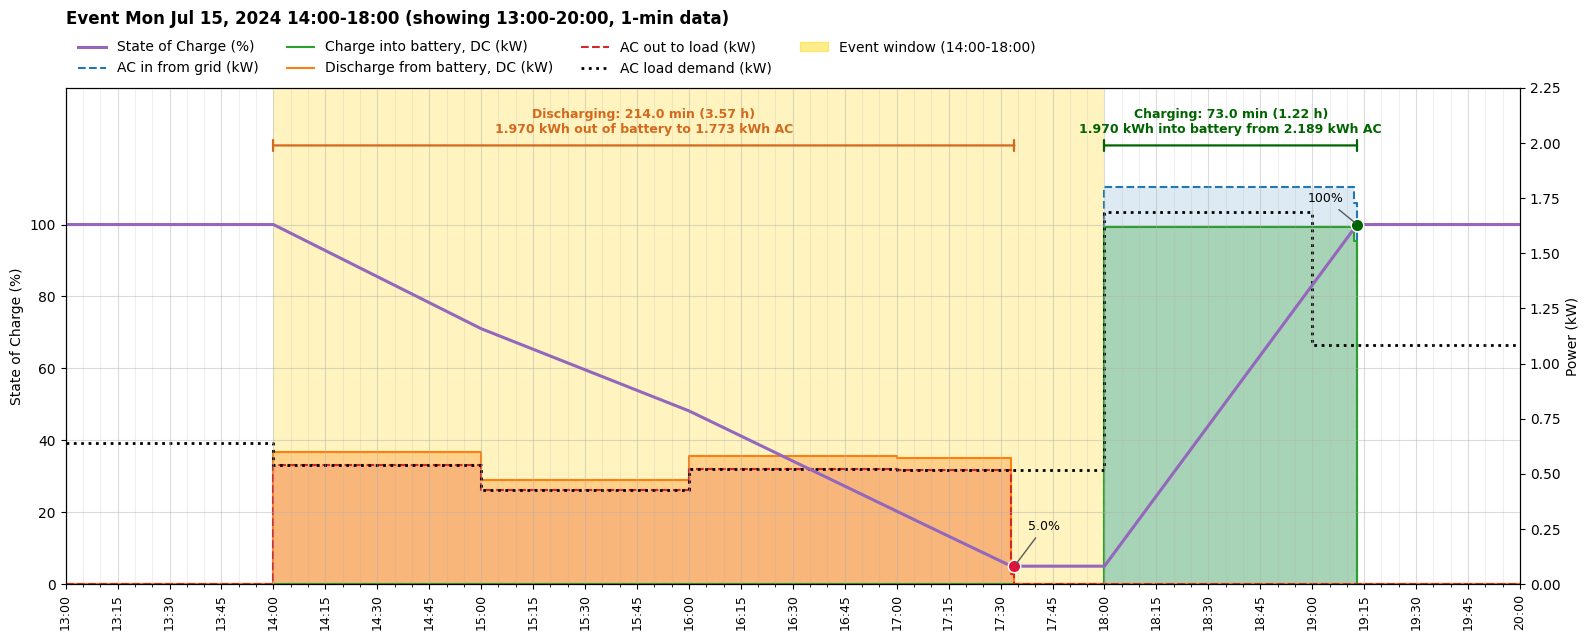

Event: Mon Jul 15 14:00 - 18:00 (4 h) | window shown: 13:00 - 20:00
Discharging 14:00 - 17:34 | 1.970 kWh out of battery to 1.773 kWh AC | 214.0 min (3.57 h)
Charging 18:00 - 19:13 | 1.970 kWh into battery from 2.189 kWh AC | 73.0 min (1.22 h)
Grid returns at 18:00; battery is back to 100% at 19:13 (73 min later)


In [38]:
# ---- Event zoom: state of charge with charging (AC in / DC into battery) and discharging (DC out of battery / AC out) layered on it ----
DAY = "2024-07-15"          # the day to plot
EVENT_START = "14:00"       # the event always starts at this time...
EVENT_HOURS = 4             # ...and runs for this many hours
PAD_HOURS_BEFORE = 1        # hours shown before the event starts
PAD_HOURS_AFTER = 2         # hours shown after the event ends
TICK_MINUTES = 15           # labeled tick spacing (minutes)
GRID_MINUTES = 5           # minor gridline spacing (minutes)
BLOCK_GAP_MINUTES = 5       # idle gaps shorter than this inside a charge / discharge activity count as one block
SHIFT_SOC_TO_STEP_END = True    # True: plot each SoC at the END of its time step (how HOMER reports it); False: at the start
SOC_FULL = 100.0            # % treated as "full" when marking when the battery is charged again

soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"      # kW into the battery
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"   # kW out of the battery (DC)
ac_in_col = "Rectifier Power Input"                            # kW of AC pulled from the grid into the inverter/charger
ac_out_col = "Inverter Power Output"                           # kW of AC the inverter delivers to the load
load_col = "AC Primary Load"                                   # kW of AC load demand (what the load asks for)

# ---- Window: fixed event, padded before and after ----
ev_start = pd.Timestamp(f"{DAY} {EVENT_START}")
ev_end = ev_start + pd.Timedelta(hours=EVENT_HOURS)
t_start = max(ev_start - pd.Timedelta(hours=PAD_HOURS_BEFORE), df.index[0])
t_end   = min(ev_end + pd.Timedelta(hours=PAD_HOURS_AFTER), df.index[-1] + step)
d = df.loc[t_start : t_end - step]
if d.empty:
    raise ValueError(f"No data for the {DAY} window: the data covers {df.index[0]} to {df.index[-1]}")

def clock_locator(minutes):
    """Ticks on the clock (:00, :15, ...) for spacings up to an hour, whole hours above that."""
    return mdates.MinuteLocator(byminute=range(0, 60, minutes)) if minutes <= 60 else mdates.HourLocator(interval=max(minutes // 60, 1))

def step_xy(series):
    """x/y for a step plot where each row's value holds for one full time step (adds a closing point at the end)."""
    return d.index.append(d.index[-1:] + step), np.r_[series.to_numpy(), series.iloc[-1]]

def find_blocks(series):
    """(first row, last row) of each run of rows with power > 0; idle gaps shorter than BLOCK_GAP_MINUTES are merged."""
    idx = series.index[series > 1e-9]
    if len(idx) == 0:
        return []
    max_gap, blocks, first, prev = pd.Timedelta(minutes=BLOCK_GAP_MINUTES), [], idx[0], idx[0]
    for t in idx[1:]:
        if t - prev - step > max_gap:               # idle time between the two active rows
            blocks.append((first, prev)); first = t
        prev = t
    blocks.append((first, prev))
    return blocks

Y_TOP, Y_BRACKET = 138, 122                         # headroom above 100% SoC for the block labels
fig, ax = plt.subplots(figsize=(16, 6.5))
ax_p = ax.twinx()                                   # battery power (kW): drawn first, so it sits behind the SoC line

# Event window (behind everything)
ax_p.axvspan(ev_start, ev_end, color="gold", alpha=0.25, lw=0)

# Layers on the right axis, back to front. The larger side of each pair is drawn first, so the gap between the two
# is the conversion loss:  charging = AC input (larger) then charge into battery;  discharging = DC out of battery (larger) then AC out.
power_handles, p_max = [], 0.0
layers = [(ac_in_col, "tab:blue", 0.15, "AC in from grid (kW)"),
          (chg_col, "tab:green", 0.30, "Charge into battery, DC (kW)"),
          (dis_col, "tab:orange", 0.30, "Discharge from battery, DC (kW)"),
          (ac_out_col, "tab:red", 0.15, "AC out to load (kW)")]
for col, color, alpha, label in layers:
    if col not in d.columns:
        continue
    x, y = step_xy(d[col])
    ax_p.fill_between(x, y, step="post", color=color, alpha=alpha, lw=0)
    line, = ax_p.plot(x, y, drawstyle="steps-post", color=color, lw=1.5, ls="--" if col in (ac_in_col, ac_out_col) else "-", label=label)
    power_handles.append(line)
    p_max = max(p_max, d[col].max())
# AC load demand on top, as a line only: where it sits above "AC out to load" the load is not being fully served
if load_col in d.columns:
    x, y = step_xy(d[load_col])
    l_load, = ax_p.plot(x, y, drawstyle="steps-post", color="black", lw=2.0, ls=":", label="AC load demand (kW)")
    power_handles.append(l_load)
    p_max = max(p_max, d[load_col].max())
ax_p.set_ylim(0, p_max * 1.25 if p_max > 0 else 1)
ax_p.set_ylabel("Power (kW)")

# State of charge (left axis), drawn on top of the power layers
ax.set_zorder(ax_p.get_zorder() + 1)
ax.patch.set_visible(False)
if SHIFT_SOC_TO_STEP_END:
    # HOMER's SoC in each row is the value at the END of that time step, so it belongs one step later on the time axis.
    # Start one row early so the curve has no gap on the left.
    soc = df[soc_col].loc[t_start - step : d.index[-1]].copy()
    soc.index = soc.index + step
else:
    soc = d[soc_col].copy()
l_soc, = ax.plot(soc.index, soc, color="tab:purple", lw=2.2, label="State of Charge (%)")
ax.set(ylabel="State of Charge (%)")
ax.set_ylim(0, Y_TOP)                      # always starts at 0; headroom above 100% for labels
ax.set_yticks(range(0, 101, 20))

def mark(t, v, text, color, dy=14):
    """Dot on the SoC curve with a label; the label flips to the left near the right edge of the plot."""
    ax.plot(t, v, marker="o", ms=9, mfc=color, mec="white", ls="none", zorder=5, clip_on=False)
    frac = (t - soc.index[0]) / (soc.index[-1] - soc.index[0])
    ha, dx = ("right", -10) if frac > 0.85 else ("left", 10)
    ax.annotate(text, xy=(t, v), xytext=(dx, dy), textcoords="offset points", ha=ha, va="bottom", fontsize=9,
                arrowprops=dict(arrowstyle="-", color="0.35"), zorder=6)

# Label the SoC minimum and when the battery is full again
full_t = None
if soc.max() == soc.min():
    mark(soc.idxmax(), soc.max(), f"Constant {soc.max():.1f}%", "gray")
else:
    t_min = soc.idxmin()
    mark(t_min, soc.loc[t_min], f"{soc.loc[t_min]:.1f}%", "crimson", dy=24)
    after = soc.loc[t_min:]
    back = after[after >= SOC_FULL - 0.01]
    if len(back):
        full_t = back.index[0]
        mark(full_t, back.iloc[0], f"{SOC_FULL:.0f}%", "darkgreen")

# ---- Label each charging / discharging block with its total energy and time ----
# Charge time = energy / full charge rate (exact at any time step); discharge time = active rows x time step.
rated_kw = df[chg_col].max()
summary_lines = []
for name, col, color in [("Discharging", dis_col, "chocolate"), ("Charging", chg_col, "darkgreen")]:
    for first, last in find_blocks(d[col]):
        rows = d.loc[first:last]
        kwh = to_kwh(rows[col])
        hours = kwh / rated_kw if col == chg_col else to_hours((rows[col] > 1e-9).sum())
        block_end = min(first + pd.Timedelta(hours=hours), last + step) if col == chg_col else last + step
        if col == chg_col:
            ac = f" from {to_kwh(rows[ac_in_col]):.3f} kWh AC" if ac_in_col in rows.columns else ""
            detail = f"{kwh:.3f} kWh into battery{ac}"
        else:
            ac = f" to {to_kwh(rows[ac_out_col]):.3f} kWh AC" if ac_out_col in rows.columns else ""
            detail = f"{kwh:.3f} kWh out of battery{ac}"
        ax.annotate("", xy=(first, Y_BRACKET), xytext=(block_end, Y_BRACKET),
                    arrowprops=dict(arrowstyle="|-|", color=color, lw=1.6, shrinkA=0, shrinkB=0, mutation_scale=4))
        ax.text(first + (block_end - first) / 2, Y_BRACKET + 2.5, f"{name}: {hours * 60:.1f} min ({hours:.2f} h)\n{detail}",
                ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")
        summary_lines.append(f"{name} {first:%H:%M} - {last + step:%H:%M} | {detail} | {hours * 60:.1f} min ({hours:.2f} h)")

ax.set_title(f"Event {ev_start:%a %b %d, %Y} {ev_start:%H:%M}-{ev_end:%H:%M} "
             f"(showing {t_start:%H:%M}-{t_end:%H:%M}, {step_min:g}-min data)", loc="left", fontweight="bold", pad=46)
ax.legend(handles=[l_soc] + power_handles + [Patch(color="gold", alpha=0.45, label=f"Event window ({ev_start:%H:%M}-{ev_end:%H:%M})")],
          loc="lower left", bbox_to_anchor=(0, 1.0), ncol=4, frameon=False)

# X-axis: labeled ticks every TICK_MINUTES, gridlines every GRID_MINUTES
ax.xaxis.set_major_locator(clock_locator(TICK_MINUTES))
ax.xaxis.set_minor_locator(clock_locator(GRID_MINUTES))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.tick_params(axis="x", which="major", labelsize=9, labelrotation=90)
ax.set_xlim(d.index[0], d.index[-1] + step)
ax.grid(which="minor", axis="x", alpha=0.20)
ax.grid(which="major", axis="y", alpha=0.45)
ax.grid(which="major", axis="x", alpha=0.45)

plt.tight_layout()
fig.savefig(f"plots/event_zoom_{DAY}_{ts()}.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Key times and energy for this window ----
print(f"Event: {ev_start:%a %b %d %H:%M} - {ev_end:%H:%M} ({EVENT_HOURS} h) | window shown: {t_start:%H:%M} - {t_end:%H:%M}")
print("\n".join(summary_lines) if summary_lines else "No charging or discharging in this window.")
if full_t is not None:
    print(f"Grid returns at {ev_end:%H:%M}; battery is back to {SOC_FULL:.0f}% at {full_t:%H:%M} "
          f"({(full_t - ev_end) / pd.Timedelta(minutes=1):.0f} min later)")

# Power Station data

In [39]:
hardware_df = pd.read_csv('../data/PowerStations_LiFePo4_June29_2026.csv')

#clean data - these columns aren't used in this analysis
hardware_df = hardware_df.drop(columns=['Link','Min PV Voltage','Max PV Voltage','Warranty Years','Lifespan','Notes','Estimated Full Charge Time','Estimated Minimum Grid Charge Efficiency'])

retailPriceColumns = ['Retail Price (3/14/2026)']


In [40]:
pC = []
for c in hardware_df.columns:
    if 'Price (' in c:
        pC.append(c)

#get average retail prices
hardware_df['retail price']= hardware_df[retailPriceColumns].mean(axis=1)
hardware_df = hardware_df.drop(columns=pC) #drop raw price data

hardware_df = hardware_df.dropna(subset=['retail price']) #drop rows with missing avg prices

In [41]:
BATTERY_MODEL = 'Elite 200V2'

hardware_df = hardware_df[hardware_df['Model']==BATTERY_MODEL]

hardware_df['80 Per Grid Charge Hours'] = hardware_df['Full Grid Charge Hours'] * 0.6548

#convert percentage to decimal
hardware_df['Inverter Efficiency'] = hardware_df['Inverter Efficiency']*.01

# price per Wh
hardware_df['$/Wh'] = hardware_df['retail price']/hardware_df['Battery Wh']

In [42]:
hardware_df

,Make,Model,Battery Wh,Max PV Watts,Max PV Amps,Inverter Watts,Max AC Input Watts,Full Grid Charge Hours,80 Per Grid Charge Hours,Inverter Efficiency,Cycles,DoD,Passthrough,community API,official API,potential API,retail price,$/Wh
28,Bluetti,Elite 200V2,2073.0,1000,20.0,2600.0,1800.0,1.4,0.91672,0.9,6000,80,NaN,True,True,False,799.0,0.385432


In [43]:
# ---- Pull the Elite 200V2 spec directly from hardware_df, instead of hardcoding ----

elite_row = hardware_df[hardware_df['Model'] == 'Elite 200V2'].iloc[0]

ELITE_200V2_SPEC = {
    'battery_Wh': float(elite_row['Battery Wh']),
    'max_pv_W': int(elite_row['Max PV Watts']),
    'max_pv_A': float(elite_row['Max PV Amps']),
    'inverter_W': float(elite_row['Inverter Watts']),
    'max_ac_input_W': float(elite_row['Max AC Input Watts']),
    'full_grid_charge_hours': float(elite_row['Full Grid Charge Hours']),
    'inverter_efficiency': float(elite_row['Inverter Efficiency']),
    'rectifier_efficiency': 0.9,
    'cycles': int(elite_row['Cycles']),
    'dod': float(elite_row['DoD']) / 100.0,   # hardware_df stores DoD as 80, not 0.80
    'retail_price': float(elite_row['retail price']),
}

print(ELITE_200V2_SPEC)

{'battery_Wh': 2073.0, 'max_pv_W': 1000, 'max_pv_A': 20.0, 'inverter_W': 2600.0, 'max_ac_input_W': 1800.0, 'full_grid_charge_hours': 1.4, 'inverter_efficiency': 0.9, 'rectifier_efficiency': 0.9, 'cycles': 6000, 'dod': 0.8, 'retail_price': 799.0}


In [44]:
#estimated charge time 5%-100%
print('CHARGING')
requiredDCinput_W = ELITE_200V2_SPEC['battery_Wh'] * 0.95
print(f'DC energy needed: {requiredDCinput_W}W')
requiredACinput_W = requiredDCinput_W / .9
print(f'AC energy needed: {requiredACinput_W}W')
predictedChargeTime_minutes = (requiredACinput_W/ELITE_200V2_SPEC['max_ac_input_W']) * 60
print(f'Estimated fastest charge time:{predictedChargeTime_minutes} minutes')

CHARGING
DC energy needed: 1969.35W
AC energy needed: 2188.1666666666665W
Estimated fastest charge time:72.93888888888888 minutes


In [45]:
ACin_W = 100
ACout_W = 100

# charging equation
DCin_W = ACin_W / .9

# discharging equation
DCout_W = ACout_W / .9

In [46]:
# CHARGING TIME
SOC = 0.05
charging_efficiency = 0.9

max_energy_in_minute_WAC = (ELITE_200V2_SPEC['max_ac_input_W']/60)
max_energy_in_minute_WDC = max_energy_in_minute_WAC*charging_efficiency

# charging - runs until battery is full
charging_minutes=0
total_energy_WhAC = 0
while SOC < 1:
    SOC += (max_energy_in_minute_WDC / ELITE_200V2_SPEC['battery_Wh'])
    charging_minutes+=1
    if SOC < 1:
        total_energy_WhAC+=max_energy_in_minute_WAC
    else:
        excess_AC = (SOC - 1) *ELITE_200V2_SPEC['battery_Wh']/0.9
        total_energy_WhAC+=max_energy_in_minute_WAC - excess_AC
    #print(SOC)

print(f'time: {charging_minutes} minutes')
print(f'AC energy from grid: {total_energy_WhAC}Wh')

# charging equation
#DCin_W = ACin_W / .9

time: 73 minutes
AC energy from grid: 2188.16666666667Wh


In [47]:
# ---- AC load for the event window ----
DAY = "2024-07-15"          # the day to plot
EVENT_START = "14:00"       # the event always starts at this time...
EVENT_HOURS = 4             # ...and runs for this many hours
PAD_HOURS_BEFORE = 1        # hours shown before the event starts
PAD_HOURS_AFTER = 2         # hours shown after the event ends
TICK_MINUTES = 15           # labeled tick spacing (minutes)
GRID_MINUTES = 5            # minor gridline spacing (minutes)

load_col = "AC Primary Load"    # kW of AC load demand (what the load asks for)

# ---- Window: fixed event, padded before and after ----
ev_start = pd.Timestamp(f"{DAY} {EVENT_START}")
ev_end = ev_start + pd.Timedelta(hours=EVENT_HOURS)
t_start = max(ev_start, df.index[0])
t_end   = min(ev_end, df.index[-1] + step)
d = df.loc[t_start : t_end - step]
if d.empty:
    raise ValueError(f"No data for the {DAY} window: the data covers {df.index[0]} to {df.index[-1]}")

d.head()

,AC Primary Load,AC Primary Load Served,Deferrable Load Served,Deferrable Load Storage Level,Grid Power Price,Grid Sellback Rate,Grid Purchases,Total Electrical Load Served,Renewable Penetration,Unmet Electrical Load,Capacity Shortage,Total Renewable Power Output,Inverter Power Input,Inverter Power Output,Rectifier Power Input,Rectifier Power Output,Elite 200V2 LFP 2kWh DC Coupled Maximum Charge Power,Elite 200V2 LFP 2kWh DC Coupled Maximum Discharge Power,Elite 200V2 LFP 2kWh DC Coupled Charge Power,Elite 200V2 LFP 2kWh DC Coupled Discharge Power,Elite 200V2 LFP 2kWh DC Coupled Input Power,Elite 200V2 LFP 2kWh DC Coupled Energy Content,Elite 200V2 LFP 2kWh DC Coupled State of Charge,Elite 200V2 LFP 2kWh DC Coupled Energy Cost,AC Required Operating Capacity,DC Required Operating Capacity,AC Operating Capacity,DC Operating Capacity,event
Time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-07-15 14:00:00,0.5405,0.5405,0,0,-999.0,0,0.0,0.5405,0,0.0,0.0,0,0.600555,0.5405,0.0,0.0,0.000000,2.16,0.0,0.600555,-0.600555,2.063591,99.51730,0.333333,0.594549,0,0,2.16,True
2024-07-15 14:01:00,0.5405,0.5405,0,0,-999.0,0,0.0,0.5405,0,0.0,0.0,0,0.600555,0.5405,0.0,0.0,0.600555,2.16,0.0,0.600555,-0.600555,2.053581,99.03460,0.333333,0.594549,0,0,2.16,True
2024-07-15 14:02:00,0.5405,0.5405,0,0,-999.0,0,0.0,0.5405,0,0.0,0.0,0,0.600555,0.5405,0.0,0.0,1.201110,2.16,0.0,0.600555,-0.600555,2.043572,98.55190,0.333333,0.594549,0,0,2.16,True
2024-07-15 14:03:00,0.5405,0.5405,0,0,-999.0,0,0.0,0.5405,0,0.0,0.0,0,0.600555,0.5405,0.0,0.0,1.620000,2.16,0.0,0.600555,-0.600555,2.033563,98.06921,0.333333,0.594549,0,0,2.16,True
2024-07-15 14:04:00,0.5405,0.5405,0,0,-999.0,0,0.0,0.5405,0,0.0,0.0,0,0.600555,0.5405,0.0,0.0,1.620000,2.16,0.0,0.600555,-0.600555,2.023554,97.58650,0.333333,0.594549,0,0,2.16,True


In [48]:
SOC = 1
floor = 0.05
inverter_efficiency = 0.9

print('DISCHARGING')
max_output_WDC = ELITE_200V2_SPEC['battery_Wh'] * 0.95
print(f'max DC output: {max_output_WDC}W')
max_output_WAC = max_output_WDC * .9
print(f'max AC output: {max_output_WAC}W')
predictedDischargeTime_minutes = ((ELITE_200V2_SPEC['battery_Wh'] * 0.95)/(ELITE_200V2_SPEC['inverter_W']/inverter_efficiency)) * 60
print(f'Estimated fastest discharge time:{predictedDischargeTime_minutes} minutes')

max_power_out_minute_WAC = (ELITE_200V2_SPEC['inverter_W']/60)
print(f'max out: {max_power_out_minute_WAC} WAC')
max_power_out_minute_WDC = max_power_out_minute_WAC/inverter_efficiency
print(f'max out: {max_power_out_minute_WDC} WDC')

# discharging - runs until battery is at 5%
discharging_minutes=0
total_served_energy_WhAC = 0

demand_WAC = 10000000
demand_WDC = demand_WAC/inverter_efficiency
allowed_demand_WDC = min(demand_WDC,max_power_out_minute_WDC)
print('')
print('Discharging with maximum load:')
while SOC > floor:
    
    SOC -= (allowed_demand_WDC / ELITE_200V2_SPEC['battery_Wh'])
    discharging_minutes+=1
    if SOC >= floor:
        total_served_energy_WhAC+=allowed_demand_WDC*inverter_efficiency
    else:
        excess_DC = (floor - SOC) *ELITE_200V2_SPEC['battery_Wh']
        total_served_energy_WhAC+=(allowed_demand_WDC - excess_DC)*inverter_efficiency

print(f'time: {discharging_minutes} minutes')
print(f'AC energy from battery via inverter: {total_served_energy_WhAC}WhAC')

# charging equation
#DCin_W = ACin_W / .9

DISCHARGING
max DC output: 1969.35W
max AC output: 1772.415W
Estimated fastest discharge time:40.90188461538462 minutes
max out: 43.333333333333336 WAC
max out: 48.14814814814815 WDC

Discharging with maximum load:
time: 41 minutes
AC energy from battery via inverter: 1772.4149999999977WhAC


In [49]:
print('model with Homer loads')

SOC = 1
floor = 0.05
inverter_efficiency = 0.9
discharging_minutes=0
total_served_energy_WhAC = 0

for l in list(d['AC Primary Load']):
    demand_WDC = (l*1000/60)/inverter_efficiency
    allowed_demand_WDC = min(demand_WDC,max_power_out_minute_WDC)
    SOC -= (allowed_demand_WDC / ELITE_200V2_SPEC['battery_Wh'])
    discharging_minutes+=1
    if SOC > floor:    
        total_served_energy_WhAC+=allowed_demand_WDC*inverter_efficiency
    else:  
        excess_DC = (floor - SOC) *ELITE_200V2_SPEC['battery_Wh']
        total_served_energy_WhAC+=(allowed_demand_WDC - excess_DC)*inverter_efficiency
        SOC = floor
        break

print(f'soc: {SOC}')
print(f'time: {discharging_minutes} minutes')
print(f'DC energy from battery via inverter: {total_served_energy_WhAC/inverter_efficiency}WhDC')
print(f'AC energy from battery via inverter: {total_served_energy_WhAC}WhAC')

model with Homer loads
soc: 0.05
time: 214 minutes
DC energy from battery via inverter: 1969.3499999999967WhDC
AC energy from battery via inverter: 1772.414999999997WhAC


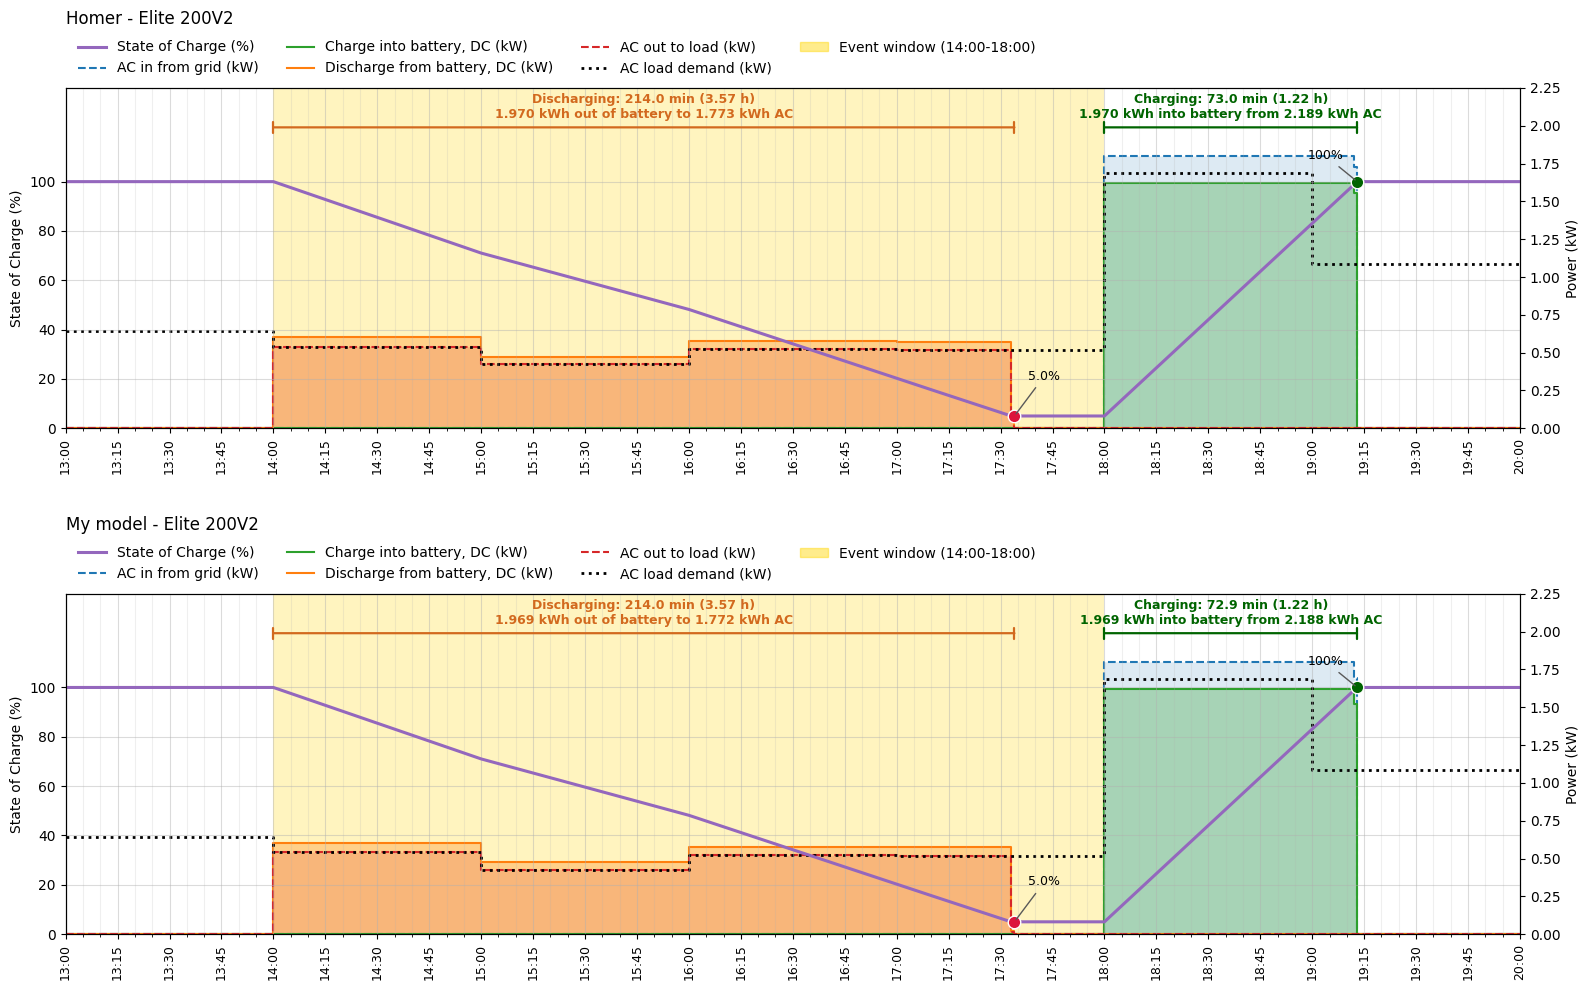

In [51]:
# ---- HOMER vs. my model: event zoom with HOMER on top and my model's simulation below (same window, load and axes) ----

DAY = "2024-07-15"          # the day to plot
EVENT_START = "14:00"       # the event always starts at this time...
EVENT_HOURS = 4             # ...and runs for this many hours
PAD_HOURS_BEFORE = 1        # hours shown before the event starts
PAD_HOURS_AFTER = 2         # hours shown after the event ends
TICK_MINUTES = 15           # labeled tick spacing (minutes)
GRID_MINUTES = 5            # minor gridline spacing (minutes)
BLOCK_GAP_MINUTES = 5       # idle gaps shorter than this inside a charge / discharge activity count as one block
SHIFT_SOC_TO_STEP_END = True    # True: plot each SoC at the END of its time step (how HOMER reports it); False: at the start
SOC_FULL = 100.0            # % treated as "full" when marking when the battery is charged again

SOC_FLOOR = 0.05                                       # the model never discharges below 5%
INV_EFF = ELITE_200V2_SPEC["inverter_efficiency"]      # DC -> AC efficiency when discharging
RECT_EFF = ELITE_200V2_SPEC["rectifier_efficiency"]    # AC -> DC efficiency when charging

soc_col = "Elite 200V2 LFP 2kWh DC Coupled State of Charge"
chg_col = "Elite 200V2 LFP 2kWh DC Coupled Charge Power"      # kW into the battery
dis_col = "Elite 200V2 LFP 2kWh DC Coupled Discharge Power"   # kW out of the battery (DC)
ac_in_col = "Rectifier Power Input"                            # kW of AC pulled from the grid into the inverter/charger
ac_out_col = "Inverter Power Output"                           # kW of AC the inverter delivers to the load
load_col = "AC Primary Load"                                   # kW of AC load demand (what the load asks for)

# ---- Window: fixed event, padded before and after ----
ev_start = pd.Timestamp(f"{DAY} {EVENT_START}")
ev_end = ev_start + pd.Timedelta(hours=EVENT_HOURS)
t_start = max(ev_start - pd.Timedelta(hours=PAD_HOURS_BEFORE), df.index[0])
t_end   = min(ev_end + pd.Timedelta(hours=PAD_HOURS_AFTER), df.index[-1] + step)
d = df.loc[t_start : t_end - step]                     # HOMER's data for the window
if d.empty:
    raise ValueError(f"No data for the {DAY} window: the data covers {df.index[0]} to {df.index[-1]}")

# ---- My model: same load as HOMER, battery starts full, grid is out during the event, recharges when the grid returns ----
cap_kwh    = ELITE_200V2_SPEC["battery_Wh"] / 1000
max_ac_out = ELITE_200V2_SPEC["inverter_W"] / 1000         # kW AC the inverter can deliver
max_dc_out = max_ac_out / INV_EFF                           # kW DC out of the battery at full inverter output
max_ac_in  = ELITE_200V2_SPEC["max_ac_input_W"] / 1000     # kW AC the rectifier can pull from the grid
max_dc_in  = max_ac_in * RECT_EFF                           # kW DC into the battery at the full charge rate
floor_kwh  = SOC_FLOOR * cap_kwh

load = d[load_col].to_numpy()                               # swap in the model's own AC load profile here if it gets one
n = len(d)
m_chg, m_dis, m_ac_in, m_ac_out, m_soc_end = (np.zeros(n) for _ in range(5))
e = cap_kwh                                                 # battery energy content (kWh): starts full
for i, t in enumerate(d.index):
    if ev_start <= t < ev_end:                              # grid down: battery serves the load through the inverter
        dc = min(load[i] / INV_EFF, max_dc_out)             # DC kW needed for the load, capped by the inverter rating
        dc = max(min(dc, (e - floor_kwh) / dt_h), 0.0)      # the last step can only use what is left above the floor
        m_dis[i], m_ac_out[i] = dc, dc * INV_EFF
        e -= dc * dt_h
    elif t >= ev_end and e < cap_kwh - 1e-9:                # grid back: recharge at the max rate until full
        dc = min(max_dc_in, (cap_kwh - e) / dt_h)           # the last step only takes what is needed to reach 100%
        m_chg[i], m_ac_in[i] = dc, dc / RECT_EFF
        e += dc * dt_h
    m_soc_end[i] = 100 * e / cap_kwh                        # SoC (%) at the END of this step

m = pd.DataFrame({chg_col: m_chg, dis_col: m_dis, ac_in_col: m_ac_in, ac_out_col: m_ac_out, load_col: load}, index=d.index)
# SoC with one extra row before the window (the starting 100%), so the shifted curve has no gap on the left
m_soc = pd.concat([pd.Series([100.0], index=[t_start - step]), pd.Series(m_soc_end, index=d.index)])
h_soc = df[soc_col].loc[t_start - step : d.index[-1]]

def clock_locator(minutes):
    """Ticks on the clock (:00, :15, ...) for spacings up to an hour, whole hours above that."""
    return mdates.MinuteLocator(byminute=range(0, 60, minutes)) if minutes <= 60 else mdates.HourLocator(interval=max(minutes // 60, 1))

def step_xy(series):
    """x/y for a step plot where each row's value holds for one full time step (adds a closing point at the end)."""
    return d.index.append(d.index[-1:] + step), np.r_[series.to_numpy(), series.iloc[-1]]

def find_blocks(series):
    """(first row, last row) of each run of rows with power > 0; idle gaps shorter than BLOCK_GAP_MINUTES are merged."""
    idx = series.index[series > 1e-9]
    if len(idx) == 0:
        return []
    max_gap, blocks, first, prev = pd.Timedelta(minutes=BLOCK_GAP_MINUTES), [], idx[0], idx[0]
    for t in idx[1:]:
        if t - prev - step > max_gap:               # idle time between the two active rows
            blocks.append((first, prev)); first = t
        prev = t
    blocks.append((first, prev))
    return blocks

Y_TOP, Y_BRACKET = 138, 122                         # headroom above 100% SoC for the block labels
power_cols = [ac_in_col, chg_col, dis_col, ac_out_col, load_col]
p_max = max(f[c].max() for f in (d, m) for c in power_cols if c in f.columns)
P_TOP = p_max * 1.25 if p_max > 0 else 1            # same power axis on both panels so they compare by eye

def draw_panel(ax, data, soc_src, rated_kw, name):
    """One event-zoom panel: SoC + power layers + charge/discharge block labels. Returns (summary lines, time battery is full again)."""
    ax_p = ax.twinx()                               # battery power (kW): drawn first, so it sits behind the SoC line
    ax_p.axvspan(ev_start, ev_end, color="gold", alpha=0.25, lw=0)

    # Layers on the right axis, back to front. The larger side of each pair is drawn first, so the gap between the two
    # is the conversion loss:  charging = AC input (larger) then charge into battery;  discharging = DC out of battery (larger) then AC out.
    power_handles = []
    layers = [(ac_in_col, "tab:blue", 0.15, "AC in from grid (kW)"),
              (chg_col, "tab:green", 0.30, "Charge into battery, DC (kW)"),
              (dis_col, "tab:orange", 0.30, "Discharge from battery, DC (kW)"),
              (ac_out_col, "tab:red", 0.15, "AC out to load (kW)")]
    for col, color, alpha, label in layers:
        if col not in data.columns:
            continue
        x, y = step_xy(data[col])
        ax_p.fill_between(x, y, step="post", color=color, alpha=alpha, lw=0)
        line, = ax_p.plot(x, y, drawstyle="steps-post", color=color, lw=1.5, ls="--" if col in (ac_in_col, ac_out_col) else "-", label=label)
        power_handles.append(line)
    # AC load demand on top, as a line only: where it sits above "AC out to load" the load is not being fully served
    if load_col in data.columns:
        x, y = step_xy(data[load_col])
        l_load, = ax_p.plot(x, y, drawstyle="steps-post", color="black", lw=2.0, ls=":", label="AC load demand (kW)")
        power_handles.append(l_load)
    ax_p.set_ylim(0, P_TOP)
    ax_p.set_ylabel("Power (kW)")

    # State of charge (left axis), drawn on top of the power layers
    ax.set_zorder(ax_p.get_zorder() + 1)
    ax.patch.set_visible(False)
    if SHIFT_SOC_TO_STEP_END:
        # The SoC in each row is the value at the END of that time step, so it belongs one step later on the time axis.
        soc = soc_src.copy()
        soc.index = soc.index + step
    else:
        soc = soc_src.loc[t_start:].copy()
    l_soc, = ax.plot(soc.index, soc, color="tab:purple", lw=2.2, label="State of Charge (%)")
    ax.set(ylabel="State of Charge (%)")
    ax.set_ylim(0, Y_TOP)                      # always starts at 0; headroom above 100% for labels
    ax.set_yticks(range(0, 101, 20))

    def mark(t, v, text, color, dy=14):
        """Dot on the SoC curve with a label; the label flips to the left near the right edge of the plot."""
        ax.plot(t, v, marker="o", ms=9, mfc=color, mec="white", ls="none", zorder=5, clip_on=False)
        frac = (t - soc.index[0]) / (soc.index[-1] - soc.index[0])
        ha, dx = ("right", -10) if frac > 0.85 else ("left", 10)
        ax.annotate(text, xy=(t, v), xytext=(dx, dy), textcoords="offset points", ha=ha, va="bottom", fontsize=9,
                    arrowprops=dict(arrowstyle="-", color="0.35"), zorder=6)

    # Label the SoC minimum and when the battery is full again
    full_t = None
    if soc.max() == soc.min():
        mark(soc.idxmax(), soc.max(), f"Constant {soc.max():.1f}%", "gray")
    else:
        t_min = soc.idxmin()
        mark(t_min, soc.loc[t_min], f"{soc.loc[t_min]:.1f}%", "crimson", dy=24)
        after = soc.loc[t_min:]
        back = after[after >= SOC_FULL - 0.01]
        if len(back):
            full_t = back.index[0]
            mark(full_t, back.iloc[0], f"{SOC_FULL:.0f}%", "darkgreen")

    # Label each charging / discharging block with its total energy and time
    # Charge time = energy / full charge rate (exact at any time step); discharge time = active rows x time step.
    summary_lines = []
    for label_txt, col, color in [("Discharging", dis_col, "chocolate"), ("Charging", chg_col, "darkgreen")]:
        for first, last in find_blocks(data[col]):
            rows = data.loc[first:last]
            kwh = to_kwh(rows[col])
            hours = kwh / rated_kw if col == chg_col else to_hours((rows[col] > 1e-9).sum())
            block_end = min(first + pd.Timedelta(hours=hours), last + step) if col == chg_col else last + step
            if col == chg_col:
                ac = f" from {to_kwh(rows[ac_in_col]):.3f} kWh AC" if ac_in_col in rows.columns else ""
                detail = f"{kwh:.3f} kWh into battery{ac}"
            else:
                ac = f" to {to_kwh(rows[ac_out_col]):.3f} kWh AC" if ac_out_col in rows.columns else ""
                detail = f"{kwh:.3f} kWh out of battery{ac}"
            ax.annotate("", xy=(first, Y_BRACKET), xytext=(block_end, Y_BRACKET),
                        arrowprops=dict(arrowstyle="|-|", color=color, lw=1.6, shrinkA=0, shrinkB=0, mutation_scale=4))
            ax.text(first + (block_end - first) / 2, Y_BRACKET + 2.5, f"{label_txt}: {hours * 60:.1f} min ({hours:.2f} h)\n{detail}",
                    ha="center", va="bottom", fontsize=9, color=color, fontweight="bold")
            summary_lines.append(f"{label_txt} {first:%H:%M} - {last + step:%H:%M} | {detail} | {hours * 60:.1f} min ({hours:.2f} h)")

    ax.set_title(f"{name} - Elite 200V2", loc="left", pad=46)
    ax.legend(handles=[l_soc] + power_handles + [Patch(color="gold", alpha=0.45, label=f"Event window ({ev_start:%H:%M}-{ev_end:%H:%M})")],
              loc="lower left", bbox_to_anchor=(0, 1.0), ncol=4, frameon=False)

    # X-axis: labeled ticks every TICK_MINUTES, gridlines every GRID_MINUTES
    ax.xaxis.set_major_locator(clock_locator(TICK_MINUTES))
    ax.xaxis.set_minor_locator(clock_locator(GRID_MINUTES))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.tick_params(axis="x", which="major", labelsize=9, labelrotation=90)
    ax.set_xlim(d.index[0], d.index[-1] + step)
    ax.grid(which="minor", axis="x", alpha=0.20)
    ax.grid(which="major", axis="y", alpha=0.45)
    ax.grid(which="major", axis="x", alpha=0.45)
    return summary_lines, full_t

# ---- Draw: HOMER on top, my model below ----
fig, (ax_h, ax_m) = plt.subplots(2, 1, figsize=(16, 10))
h_lines, h_full = draw_panel(ax_h, d, h_soc, df[chg_col].max(), "Homer")
m_lines, m_full = draw_panel(ax_m, m, m_soc, max_dc_in, "My model")
fig.tight_layout(h_pad=3)
os.makedirs("plots", exist_ok=True)
fig.savefig(f"plots/Elite200v2_homer_vs_model_{DAY}_{ts()}.png", dpi=150, bbox_inches="tight")
plt.show()

In [54]:
100*2.189/2.188

100.04570383912248

In [57]:
# ---- Summary of differences: HOMER vs. my model (discharging and charging) ----
# Run the "HOMER vs. my model" block first: this uses its d, m, h_soc, m_soc.

WH = dt_h * 1000                                               # kW held for one time step -> Wh
h_soc_w, m_soc_w = h_soc.loc[d.index], m_soc.loc[d.index]      # SoC at the END of each minute

def active_rows(col):
    """Every minute from the first to the last one where HOMER or the model is active (power > 0) in this column."""
    on = (d[col] > 1e-9) | (m[col] > 1e-9)
    if not on.any():
        return None
    on_idx = on[on].index
    return d.index[(d.index >= on_idx[0]) & (d.index <= on_idx[-1])]

def corr(h, mo):
    """Pearson correlation; NaN when either series is constant (correlation is undefined then)."""
    return np.nan if len(h) < 3 or h.std() < 1e-12 or mo.std() < 1e-12 else float(np.corrcoef(h, mo)[0, 1])

def summarize(phase, label, h, mo, is_energy):
    """One summary row. Differences are MODEL - HOMER, in the units of the quantity."""
    diff = mo - h
    return {"phase": phase, "quantity": label, "minutes": len(h), "correlation r": corr(h, mo),
            "mean diff": diff.mean(), "MAE": diff.abs().mean(), "RMSE": np.sqrt((diff ** 2).mean()), "max |diff|": diff.abs().max(),
            "HOMER total (Wh)": h.sum() if is_energy else np.nan,
            "MODEL total (Wh)": mo.sum() if is_energy else np.nan,
            "total diff (%)": 100 * (mo.sum() - h.sum()) / h.sum() if is_energy and h.sum() > 0 else np.nan}

summary_rows = []
idx = active_rows(dis_col)
if idx is not None:
    summary_rows += [
        summarize("Discharging", "DC out of battery (Wh/min)", d.loc[idx, dis_col] * WH, m.loc[idx, dis_col] * WH, True),
        summarize("Discharging", "SoC at end (%)", h_soc_w.loc[idx], m_soc_w.loc[idx], False)]
idx = active_rows(chg_col)
if idx is not None:
    summary_rows += [
        summarize("Charging", "AC in from grid (Wh/min)", d.loc[idx, ac_in_col] * WH, m.loc[idx, ac_in_col] * WH, True),
        summarize("Charging", "DC into battery (Wh/min)", d.loc[idx, chg_col] * WH, m.loc[idx, chg_col] * WH, True),
        summarize("Charging", "SoC at end (%)", h_soc_w.loc[idx], m_soc_w.loc[idx], False)]

summary = pd.DataFrame(summary_rows).set_index(["phase", "quantity"])
num_cols = summary.columns.difference(["minutes"])
summary[num_cols] = summary[num_cols].round(3) + 0.0           # + 0.0 turns -0.0 into 0.0
print("=== HOMER vs. my model: differences are MODEL - HOMER, over the minutes where either one is active ===")
display(summary.fillna("-"))

for name, col in [("Discharging", dis_col), ("Charging", chg_col)]:
    h_min = to_hours((d[col] > 1e-9).sum()) * 60
    m_min = to_hours((m[col] > 1e-9).sum()) * 60
    print(f"{name} lasts: HOMER {h_min:.0f} min | MODEL {m_min:.0f} min | diff {round(m_min - h_min, 1) + 0.0:+.1f} min")

=== HOMER vs. my model: differences are MODEL - HOMER, over the minutes where either one is active ===


minutes  correlation r  mean diff    MAE   RMSE  max |diff| HOMER total (Wh) MODEL total (Wh) total diff (%)
phase       quantity                                                                                                                                
Discharging DC out of battery (Wh/min)      214            1.0     -0.003  0.003  0.039       0.570          1969.92          1969.35         -0.029
            SoC at end (%)                  214            1.0     -0.014  0.014  0.016       0.027                -                -              -
Charging    AC in from grid (Wh/min)         73            1.0     -0.009  0.009  0.074       0.633           2188.8         2188.167         -0.029
            DC into battery (Wh/min)         73            1.0     -0.008  0.008  0.067       0.570          1969.92          1969.35         -0.029
            SoC at end (%)                   73            1.0      0.014  0.014  0.016       0.027                -                -              -

Discharging lasts: HOMER 214 min | MODEL 214 min | diff +0.0 min
Charging lasts: HOMER 73 min | MODEL 73 min | diff +0.0 min
